In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import numpy as np
from datetime import datetime
np.NaN=np.nan
import pandas_ta as ta
import importlib
from typing import Tuple
import vectorbt as vbt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tqdm 
from tabulate import tabulate
import warnings
import re
import time
from tvDatafeed import TvDatafeed, Interval

warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)


In [3]:
import pandas as pd

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) 
pd.set_option('display.max_colwidth', None)

##### These variables can be changed


# 📊 Quantitative Momentum Strategy - Indian Market Adaptation

## Overview
This notebook implements the **Quantitative Momentum** framework adapted for the Indian stock market (NSE/BSE), based on the book by Wesley Gray and Jack Vogel.

---

## 🔑 Key Adaptations for Indian Market

### 1. **Rebalancing Schedule**
- **US Market:** December fiscal year-end → January effect
- **Indian Market:** March 31st fiscal year-end → April effect
- **Our Schedule:** Quarterly rebalancing at end of **Feb / May / Aug / Nov**
  - Captures both Indian fiscal quarters (Mar/Jun/Sep/Dec)
  - Front-runs window dressing by mutual funds and institutions
  - Avoids the "April Effect" (Indian equivalent of January Effect)

### 2. **12-2 Momentum (52-4 weeks)**
- **Lookback:** 52 weeks (12 months)
- **Skip Recent:** 4 weeks (1 month)
- **Why:** Avoids short-term reversals while capturing persistent trends
- **Z-Score Period:** Matches ID Score period for logical consistency

### 3. **ID Score (Intermediate Duration) - Quality Filter**
- **Purpose:** Measure "smoothness" of price path
- **Formula:** Sum of squared daily returns over lookback period
- **Interpretation:**
  - **Lower ID** = Smoother uptrend = "Frog in warm pan" = **Better**
  - **Higher ID** = Choppy/volatile path = "Frog in boiling water" = **Worse**
- **Filter:** Keep top 50% smoothest stocks (configurable via `ID_PERCENTILE_CUTOFF`)

### 4. **VIX-Based Tactical Dilution**
- **Trigger:** India VIX spike detection
- **Action:** Reduce portfolio to top 15 positions (configurable)
- **Purpose:** Risk management during volatile periods

---

## 📋 Configuration Parameters

### Core Momentum Parameters
- `ROLLING_PERIOD = 52` - 12-month lookback
- `SKIP_RECENT_WEEKS = 4` - Skip last month for 12-2 momentum
- `MEAN_PERIOD = 52` - Should match rolling period

### ID Score Quality Filter
- `USE_ID_FILTER = True` - Enable quality filtering
- `ID_LOOKBACK_WEEKS = 52` - Same as momentum period
- `ID_SKIP_WEEKS = 4` - Same as momentum skip
- `ID_PERCENTILE_CUTOFF = 50` - Keep top 50% smoothest stocks

### Portfolio Construction
- `REBALANCE_MODE = 'quarterly'` - Indian market quarterly schedule
- `NUM_STOCKS_ACTIVE = 30` - Target portfolio size
- `ZSCORE_THRESHOLD = 0.1` - Minimum momentum to qualify
- `DILUTE_TO = 15` - VIX panic dilution target

---

## 🔬 Strategy Logic Flow

1. **Data Preparation**
   - Fetch OHLCV data for universe (Nifty 500 recommended)
   - Generate weekly resampled data
   - Create date mapping for rebalancing schedule

2. **Signal Generation**
   - Calculate 12-2 Z-Scores (52-week lookback, skip last 4 weeks)
   - Calculate ID Scores (path smoothness metric)
   - Both use the same lookback window for consistency

3. **Stock Selection** (at each rebalancing)
   - Filter stocks with Z-Score >= threshold (momentum requirement)
   - Apply ID Score filter: Keep top X% smoothest stocks (quality requirement)
   - Select top N stocks by Z-Score from the quality-filtered set

4. **Risk Management**
   - Regular rebalancing: Feb/May/Aug/Nov
   - VIX-triggered dilution: Reduce to 15 stocks during spikes
   - Equal-weight portfolio construction

---

## 📈 Expected Benefits

### Vs. Traditional Momentum
- **Reduced Crashes:** ID filter removes "boiling water" stocks prone to reversal
- **Smoother Equity Curve:** Lower volatility from quality filtering
- **Better Risk-Adjusted Returns:** Higher Sharpe ratio expected

### Vs. US Implementation
- **Fiscal Alignment:** Timing matches Indian institutional behavior
- **Tax Efficiency:** Avoids April effect (tax-loss harvesting reversal)
- **Market Microstructure:** Adapted for NSE trading patterns

---

## ⚠️ Important Notes

1. **Universe Selection:** Use Nifty 200 or Nifty 500
   - Nifty 50 is too small for this strategy
   - Smallcap 250 is too volatile (ruins ID scores)

2. **Warm-up Period:** First 52 weeks of data are for signal generation
   - Trading starts after sufficient lookback is available

3. **VIX Integration:** Maintains tactical risk management
   - Complements the strategic rebalancing schedule

---

## 📚 References

- Gray & Vogel (2016): "Quantitative Momentum: A Practitioner's Guide"
- NSE India Fiscal Calendar
- India VIX behavior analysis

---

## 🚀 Quick Start Guide

### Basic Workflow

```python
# 1. Configure parameters (see next cell)
ROLLING_PERIOD = 52          # 12-month momentum
SKIP_RECENT_WEEKS = 4        # Skip last month
USE_ID_FILTER = True         # Enable quality filter
REBALANCE_MODE = 'quarterly' # Indian market schedule

# 2. Fetch data (automatically handles updates)
smart_fetch_ohlcv(symbols_to_fetch, start_date=START_DATE, end_date=END_DATE)

# 3. Generate signals
z_scores_df, z_scores_mean_df = momentum_selector(...)
id_scores_df = calculate_id_score(...)  # If USE_ID_FILTER=True

# 4. Generate weights
weights_generation(...)

# 5. Backtest
backtester = Backtester(data, INITIAL_CAPITAL, TRADING_START_DATE)
backtester.run()
portfolio = backtester.vectorbt_run(...)
```

### Testing Different Configurations

**A. Traditional Momentum (Baseline)**
```python
USE_ID_FILTER = False
REBALANCE_MODE = 'monthly'
ROLLING_PERIOD = 16  # Short-term
```

**B. Quantitative Momentum (Recommended)**
```python
USE_ID_FILTER = True
ID_PERCENTILE_CUTOFF = 50  # Top 50% smoothest
REBALANCE_MODE = 'quarterly'
ROLLING_PERIOD = 52
SKIP_RECENT_WEEKS = 4
```

**C. Aggressive Quality Filter**
```python
USE_ID_FILTER = True
ID_PERCENTILE_CUTOFF = 30  # Top 30% only (stricter)
```

---

In [4]:
#Input file
input_list='input/nifty500.csv'
#General variables
START_DATE = "2017-01-01"
TRADING_START_DATE = "2018-01-01"
END_DATE = "2026-01-01"                 #datetime.today().strftime('%Y-%m-%d')

# ========== QUANTITATIVE MOMENTUM PARAMETERS (Indian Market) ==========
# Zscore generation - 12-2 Momentum (52 weeks lookback, skip last 4 weeks)
LOOKBACK_PERIOD        = 52      # 12-month lookback (52 weeks)
SKIP_RECENT_WEEKS     = 4       # Skip last month (4 weeks) for 12-2 momentum
MEAN_PERIOD           = 52      # Should match ROLLING_PERIOD for consistency

# ID Score parameters (Quality Momentum Filter)
USE_ID_FILTER         = True    # Enable ID score filtering
ID_LOOKBACK_WEEKS     = 52      # Same as momentum lookback
ID_SKIP_WEEKS         = 4       # Same as momentum skip period
ID_PERCENTILE_CUTOFF  = 25      # Keep top 50% smoothest stocks (lower ID = smoother)

# Weights Generation
Z_MEAN                = False   # Use raw z-scores (not rolling mean)
REBALANCE_MODE        = 'monthly'  # "quarterly" (Feb/May/Aug/Nov) or "monthly"
INITIAL_CAPITAL       = 100000
NUM_STOCKS_ACTIVE     = 10
ZSCORE_THRESHOLD      = 0.1     # Minimum momentum to qualify

# Benchmark risk-off trigger
BENCHMARK_EXIT_MULTIPLIER = 0.95  # Exit if benchmark < 0.75 * SMA(53 weeks)

# VIX Dilution (Tactical Risk Management)
DILUTE_TO = 15

INPUT_SYMBOLS=[
  "3MINDIA",
  "AARTIIND",
  "ABB",
  "ABBOTINDIA",
  "ABFRL",
  "ABREL",
  "ACC",
  "ACE",
  "ADANIENT",
  "ADANIGREEN",
  "ADANIPORTS",
  "ADANITRANS",
  "ADVENZYMES",
  "AEGISCHEM",
  "AFFLE",
  "AIAENG"
 ]
INPUT_MODE='csv'    #'list' or 'csv'

# Fetch Data


In [5]:
username = "rialto364@gmail.com"
password = "TradingView@@123"
tv = TvDatafeed(username, password)

def clean_symbol(symbol):
    """Cleans the symbol name to be compatible with the API."""
    return re.sub(r'[^\w]', '_', symbol)
def fill_gaps_with_boundary_mean(df):

    ffill_val = df.ffill()
    bfill_val = df.bfill()
    filled_df = (ffill_val + bfill_val) / 2
    
    # 4. Fill original NaNs (Stocks starting/ending with NaNs will remain NaN)
    return df.fillna(filled_df)
def fetch_and_save_ohlcv(symbols_input, start_date=None, end_date=None, update=False):
    # --- 1. Symbol Input Processing ---
    symbols_list = []
    if isinstance(symbols_input, list):
        print("Processing symbols from the provided list.")
        symbols_list = symbols_input
    elif isinstance(symbols_input, str):
        try:
            print(f"Reading symbols from CSV file: {symbols_input}")
            symbols_list = pd.read_csv(symbols_input)['Symbol'].tolist()
        except Exception as e:
            print(f"Error reading symbols input: {e}")
            return []
    if not symbols_list:
        print("No symbols to process.")
        return []

    # --- 2. Bar Calculation Logic ---
    n_bars = 5000
    if start_date:
        start_date_dt = pd.to_datetime(start_date)
        days_diff = (datetime.now() - start_date_dt).days
        n_bars = ((days_diff * 5) // 7) + 50
        print(f"Start date provided. Calculating required bars: approx. {n_bars}")

    data_dict = {}
    failed_symbols = []
    
    # --- 3. Data Fetching Loop with Retry Logic ---
    retries = 3 
    
    print(f"--- Fetching data for {len(symbols_list)} symbols ---")
    
    # CHANGED: Use tqdm.tqdm to access the class explicitly
    for symbol in tqdm.tqdm(symbols_list, desc="Fetching Stocks", unit="symbol"):
        for attempt in range(retries):
            try:
                cleaned_symbol = clean_symbol(symbol)
                data = tv.get_hist(symbol=cleaned_symbol, exchange='NSE', interval=Interval.in_daily, n_bars=n_bars)
                time.sleep(0.5)
                
                if data is None or data.empty:
                    # CHANGED: Use tqdm.tqdm.write
                    #tqdm.tqdm.write(f"No data for {symbol} (Attempt {attempt+1}/{retries})")
                    time.sleep(0.5) 
                    continue 

                df = pd.DataFrame(data); df.index = pd.to_datetime(df.index)
                if start_date: df = df[df.index >= pd.to_datetime(start_date)]
                if end_date: df = df[df.index <= pd.to_datetime(end_date)]

                if df.empty:
                    #tqdm.tqdm.write(f"No data for {symbol} in date range.")
                    break 
                
                # Save the data using the symbol with the .NS suffix as the key
                data_dict[symbol + ".NS"] = df[['open', 'high', 'low', 'close', 'volume']]
                
                time.sleep(1) 
                break 
                
            except Exception as e:
                #tqdm.tqdm.write(f"Error processing {symbol} (Attempt {attempt + 1}/{retries}): {e}")
                
                if "Connection to remote host was lost" in str(e) and attempt < retries - 1:
                    wait_time = (attempt + 1) * 5 
                    tqdm.tqdm.write(f"Connection lost. Retrying in {wait_time} seconds...")
                    time.sleep(wait_time)
                else:
                    failed_symbols.append(symbol)
                    break 
            
    if not data_dict:
        print("No data was successfully fetched."); return failed_symbols

    # --- 4. Optimized Saving, Cleaning & Splitting Logic ---
    output_dir = "split_ohlcv_data"
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    
    master_file_path = os.path.join(output_dir, "all_ohlcv.csv")

    try:
        print("\n--- Processing Data ---")
        
        # 1. Create a Master DataFrame from the currently fetched data (No cleaning yet)
        current_master_df = pd.concat(data_dict, axis=1)
        
        # --- FIX 1: Set index name to None immediately ---
        current_master_df.index.name = None 

        # 2. Handle Update Mode (Merge current fetch with existing file)
        if update and os.path.exists(master_file_path):
            print("Update mode active: Merging with existing Master file...")
            existing_master = pd.read_csv(master_file_path, index_col=0, parse_dates=True, header=[0, 1])
            
            # --- FIX 2: Sanitize existing data ---
            if 'Date' in existing_master.index:
                print("Removing corrupted 'Date' row from existing file...")
                existing_master = existing_master.drop('Date')
            
            # Ensure index is datetime
            existing_master.index = pd.to_datetime(existing_master.index, errors='coerce')
            existing_master = existing_master[~existing_master.index.isna()]

            # Combine: update existing values with new ones
            master_df = existing_master.combine_first(current_master_df)
            master_df.update(current_master_df) 
        else:
            master_df = current_master_df

        # --- FIX 3: Ensure index name is None for the FINAL dataframe ---
        master_df.index.name = None

        # 3. CLEANING: Fill gaps (Performed ONLY on the final, combined DataFrame)
        print("Cleaning missing values (mean of boundaries)...")
        master_df = fill_gaps_with_boundary_mean(master_df)

        # 4. Save the Consolidated Master File
        master_df.to_csv(master_file_path)
        print(f"✅ Successfully saved Cleaned Master Data to '{master_file_path}'")

        # 5. Split into individual OHLCV files
        print("Splitting Master file into individual attribute files...")
        attributes = ['open', 'high', 'low', 'close', 'volume']
        
        for attr in attributes:
            # Use xs (Cross Section) to grab all columns for a specific attribute level
            attr_df = master_df.xs(attr, axis=1, level=1)
            
            # --- FIX 4: Explicitly set index name to 'Date' for single-level files ---
            attr_df.index.name = 'Date'
            
            output_file = os.path.join(output_dir, f"all_{attr}.csv")
            attr_df.to_csv(output_file)
            print(f"   -> Saved all_{attr}.csv")

    except Exception as e:
        print(f"❌ Critical Error during save/split process: {e}")
        return failed_symbols

    print(f"\nAll files saved successfully in '{output_dir}'!")
    return failed_symbols

In [6]:
def smart_fetch_ohlcv(symbols_input, start_date=None, end_date=None):
    """
    Intelligently fetches OHLCV data by checking existing data and only fetching missing ranges.
    Args:
        symbols_input: Either a list of symbols or path to CSV file
        start_date: Start date for data (YYYY-MM-DD)
        end_date: End date for data (YYYY-MM-DD)
    
    Returns:
        List of failed symbols
    """
    import os
    import pandas as pd
    from datetime import datetime
    
    # --- 1. Process Symbol Input ---
    symbols_list = []
    if isinstance(symbols_input, list):
        print("Processing symbols from the provided list.")
        symbols_list = symbols_input
    if not symbols_list:
        print("No symbols to process.")
        return []
    
    # Add .NS suffix to symbols for comparison
    requested_symbols = set([sym + ".NS" for sym in symbols_list])
    
    # --- 2. Check if existing data file exists ---
    master_file_path = "split_ohlcv_data/all_close.csv"
    
    if not os.path.exists(master_file_path):
        print("No existing data found. Performing complete fetch...")
        return fetch_and_save_ohlcv(symbols_input, start_date, end_date, update=False)
    
    # --- 3. Read existing data ---
    try:
        existing_data = pd.read_csv(master_file_path, index_col=0, parse_dates=True)
        existing_symbols = set(existing_data.columns)
        
        # Get date range of existing data
        existing_start = existing_data.index.min()
        existing_end = existing_data.index.max()
        
        print(f"\n--- Existing Data Summary ---")
        print(f"Symbols in file: {len(existing_symbols)}")
        print(f"Date range: {existing_start.date()} to {existing_end.date()}")
        
    except Exception as e:
        print(f"Error reading existing data: {e}")
        print("Performing complete fetch...")
        return fetch_and_save_ohlcv(symbols_input, start_date, end_date, update=False)
    
    # --- 4. Check if symbols match ---
    if requested_symbols != existing_symbols:
        print(f"\n⚠️ Symbol mismatch detected!")
        print("\nPerforming complete fetch with new symbol list...")
        return fetch_and_save_ohlcv(symbols_input, start_date, end_date, update=False)
    
    # --- 5. Symbols match - check date ranges ---
    print(f"\n✅ Symbols match! Checking date ranges...")
    
    requested_start = pd.to_datetime(start_date) if start_date else None
    requested_end = pd.to_datetime(end_date) if end_date else pd.Timestamp(datetime.today())
    
    needs_fetch_before = False
    needs_fetch_after = False
    needs_clip_start = False
    needs_clip_end = False
    
    # Check if we need to fetch data before existing start
    if requested_start and requested_start < existing_start:
        needs_fetch_before = True
        print(f"📥 Need to fetch data BEFORE {existing_start.date()}")
    elif requested_start and requested_start > existing_start:
        needs_clip_start = True
        print(f"✂️ Will clip data to start from {requested_start.date()}")
    # Check if we need to fetch data after existing end
    if requested_end > existing_end:
        needs_fetch_after = True
        print(f"📥 Need to fetch data AFTER {existing_end.date()}")
    elif requested_end < existing_end:
        needs_clip_end = True
        print(f"✂️ Will clip data to end at {requested_end.date()}")
    
    # --- 6. Handle fetching and clipping ---
    failed_symbols = []
    
    # Fetch missing data before
    if needs_fetch_before:
        print(f"\n--- Fetching data from {requested_start.date()} to {existing_start.date()} ---")
        failed_before = fetch_and_save_ohlcv(
            symbols_input,
            start_date=requested_start.strftime('%Y-%m-%d'),
            end_date=(existing_start - pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
            update=True
        )
        failed_symbols.extend(failed_before)
    
    # Fetch missing data after
    if needs_fetch_after:
        print(f"\n--- Fetching data from {existing_end.date()} to {requested_end.date()} ---")
        failed_after = fetch_and_save_ohlcv(
            symbols_input,
            start_date=(existing_end + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
            end_date=requested_end.strftime('%Y-%m-%d'),
            update=True
        )
        failed_symbols.extend(failed_after)
    
    # Clip data if needed
    if needs_clip_start or needs_clip_end:
        print(f"\n--- Clipping data to requested range ---")
        try:
            # Reload the master file after potential updates
            master_df = pd.read_csv("split_ohlcv_data/all_ohlcv.csv", index_col=0, parse_dates=True, header=[0, 1])
            
            # Clip to requested range
            clip_start = requested_start if requested_start else master_df.index.min()
            clip_end = requested_end if requested_end else master_df.index.max()
            
            master_df = master_df.loc[clip_start:clip_end]
            
            # Save clipped master file
            master_df.to_csv("split_ohlcv_data/all_ohlcv.csv")
            print(f"✅ Clipped master data to {master_df.index.min().date()} - {master_df.index.max().date()}")
            
            # Re-split into individual files
            print("Updating individual attribute files...")
            attributes = ['open', 'high', 'low', 'close', 'volume']
            for attr in attributes:
                attr_df = master_df.xs(attr, axis=1, level=1)
                attr_df.index.name = 'Date'
                output_file = f"split_ohlcv_data/all_{attr}.csv"
                attr_df.to_csv(output_file)
                print(f"   -> Updated all_{attr}.csv")
                
        except Exception as e:
            print(f"❌ Error during clipping: {e}")
    
    # --- 7. Report results ---
    if not needs_fetch_before and not needs_fetch_after and not needs_clip_start and not needs_clip_end:
        print(f"\n✅ All data already up to date! No fetching or clipping needed.")
    else:
        print(f"\n✅ Smart fetch completed!")
    
    # --- 8. Retry failed symbols with complete fetch ---
    if failed_symbols:
        print(f"\n⚠️ Found {len(failed_symbols)} failed symbols: {failed_symbols}")
        print(f"🔄 Retrying failed symbols with complete fetch...")
        
        retry_failed = fetch_and_save_ohlcv(
            failed_symbols,
            start_date=start_date,
            end_date=end_date,
            update=True
        )
        
        if retry_failed:
            print(f"\n❌ Still failed after retry: {retry_failed}")
            return retry_failed
        else:
            print(f"\n✅ All failed symbols successfully fetched on retry!")
            return []
    else:
        print(f"\n✅ Complete fetch successful on first try!")
        return []


In [ ]:
if INPUT_MODE=='csv':
    input_list_df = pd.read_csv(input_list)
    symbols_to_fetch = input_list_df['Symbol'].tolist()
else:
    symbols_to_fetch=INPUT_SYMBOLS
smart_fetch_ohlcv(symbols_to_fetch,start_date=START_DATE,end_date=END_DATE)

In [8]:
# Backfill missing values from the start for all CSVs in split_ohlcv_data
import os
import pandas as pd

def backfill_split_ohlcv(folder_path="split_ohlcv_data"):
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")

    files = [f for f in os.listdir(folder_path) if f.lower().endswith(".csv")]
    if not files:
        print(f"No CSV files found in {folder_path}")
        return

    for fname in sorted(files):
        fpath = os.path.join(folder_path, fname)
        try:
            if fname == "all_ohlcv.csv":
                df = pd.read_csv(fpath, header=[0, 1], index_col=0, parse_dates=True)
            else:
                df = pd.read_csv(fpath, index_col=0, parse_dates=True)

            # Backward fill from the start (top) to fill initial missing values
            df = df.bfill()

            # Save back to the same file
            df.to_csv(fpath)
            print(f"✅ Backfilled and saved: {fname}")
        except Exception as e:
            print(f"❌ Failed on {fname}: {e}")

backfill_split_ohlcv()

✅ Backfilled and saved: all_close.csv
✅ Backfilled and saved: all_high.csv
✅ Backfilled and saved: all_low.csv
✅ Backfilled and saved: all_ohlcv.csv
✅ Backfilled and saved: all_open.csv
✅ Backfilled and saved: all_volume.csv


# Zscore & Weights----------------------- 


In [9]:
def momentum_selector(lookback_weeks=53, skip_recent_weeks=4, mean_period=52, mode='normal'):
    """
    Momentum selector based on price ratio between T-12 (53 weeks) and T-1 (4 weeks).]
    Higher ratios indicate stronger momentum.
    
    Uses daily close data from split_ohlcv_data/all_close.csv, resampled weekly.
    """
    # Load daily close prices
    close_df = pd.read_csv('split_ohlcv_data/all_close.csv', parse_dates=[0])
    date_col = close_df.columns[0]
    close_df[date_col] = pd.to_datetime(close_df[date_col]).dt.normalize()
    close_df.set_index(date_col, inplace=True)

    # Weekly close (Monday label, last trading day of prior week)
    weekly_close = close_df.resample('W-MON', label='left', closed='left').last().dropna(how='all')

    # Momentum ratio: price at T-1 (4 weeks ago) / price at T-12 (53 weeks ago)
    t1_weeks = skip_recent_weeks
    t12_weeks = lookback_weeks
    momentum_ratio = weekly_close.shift(t1_weeks) / weekly_close.shift(t12_weeks)

    momentum_scores_df = momentum_ratio.replace([np.inf, -np.inf], np.nan)
    momentum_scores_mean_df = momentum_scores_df.rolling(window=mean_period).mean()

    if mode == 'normal':
        momentum_scores_df.to_csv('auxilary/z_scores.csv')
        momentum_scores_mean_df.to_csv('auxilary/z_scores_mean.csv')
        print(f"Momentum score calculation completed (T-12={t12_weeks} weeks, T-1={t1_weeks} weeks).")

    return momentum_scores_df, momentum_scores_mean_df

In [10]:
def calculate_id_score(lookback_weeks=52, skip_recent_weeks=4, mode='normal'):
    """
    Calculate Intermediate Duration (ID) Score for quality momentum filtering.
    
    The ID score measures the "smoothness" of a stock's price path.
    Lower (more negative) ID = smoother uptrend = better quality momentum.
    Higher (positive) ID = choppy path = lower quality momentum.
    
    Formula: ID = Sum of squared daily returns over period
    
    Args:
        lookback_weeks: Number of weeks to look back (default 52 for 12 months)
        skip_recent_weeks: Number of recent weeks to skip (default 4 for 1 month)
        mode: 'normal' saves to disk, 'looptest' returns without saving
    
    Returns:
        id_scores_df: DataFrame with ID scores for each stock
    """
    if INPUT_MODE == 'csv':
        symbols_df = pd.read_csv(input_list)
        symbols = symbols_df['Symbol'].tolist()
    else:
        symbols = INPUT_SYMBOLS
    
    # Load daily closing prices
    daily_close = pd.read_csv('src/all_close_dateonly.csv', parse_dates=['Date'], index_col='Date')
    
    # Calculate daily returns
    daily_returns = np.log(daily_close / daily_close.shift(1))
    
    # Number of trading days in lookback period (approx 5 days/week)
    lookback_days = lookback_weeks * 5
    skip_days = skip_recent_weeks * 5
    
    # Apply skip logic: shift data back by skip_days
    if skip_recent_weeks > 0:
        daily_returns_shifted = daily_returns.shift(skip_days)
    else:
        daily_returns_shifted = daily_returns
    
    # Calculate sum of squared returns over the lookback window
    # This measures path volatility - higher value = choppier path
    squared_returns = daily_returns_shifted ** 2
    rolling_sum_squared = squared_returns.rolling(window=lookback_days).sum()
    
    # Convert to weekly frequency to align with z-scores
    # Use the same date mapping as weekly_close
    weekly_close = pd.read_csv('src/cleaned_weekly_data.csv', parse_dates=['Date'], index_col='Date')
    
    # Resample daily ID scores to weekly (take last value of each week)
    id_scores_daily = rolling_sum_squared.copy()
    id_scores_weekly = pd.DataFrame(index=weekly_close.index, columns=daily_close.columns)
    
    # For each weekly date, find the closest daily date
    for week_date in weekly_close.index:
        # Find daily dates within this week
        mask = (id_scores_daily.index <= week_date) & (id_scores_daily.index > week_date - pd.Timedelta(days=7))
        if mask.any():
            # Take the last available daily value in this week
            last_daily_date = id_scores_daily.index[mask][-1]
            id_scores_weekly.loc[week_date] = id_scores_daily.loc[last_daily_date]
    
    # Normalize: Lower (more negative) ID is better
    # We invert the sign so that smoother paths get higher scores for filtering
    id_scores_df = -1 * id_scores_weekly
    
    # Handle inf and NaN
    id_scores_df = id_scores_df.replace([np.inf, -np.inf], np.nan)
    
    if mode == 'normal':
        id_scores_df.to_csv('auxilary/id_scores.csv')
        print(f"ID Score calculation completed (Lookback={lookback_weeks} weeks, Skip={skip_recent_weeks} weeks).")
    
    return id_scores_df

In [13]:
def weights_generation(
    start_date, 
    end_date, 
    trading_start_date,
    z_mean,
    dilute_to, 
    z_scores_df,
    z_scores_mean_df,
    id_scores_df=None,  # NEW: ID scores for quality filtering
    # --- Optional Arguments ---
    initial_capital=100000, 
    number_stocks_active=100, 
    zscore_threshold=0.0,
    use_id_filter=False,  # NEW: Enable ID filtering
    id_percentile_cutoff=50,  # NEW: Keep top X% smoothest stocks
    rebalance_mode='monthly',  # NEW: 'quarterly' or 'monthly'
    mode='incremental'
):
    """
    Generate portfolio weights using Quantitative Momentum framework.
    
    Args:
        ...existing parameters...
        id_scores_df: DataFrame with ID scores (smoothness metric)
        use_id_filter: Whether to filter by ID score quality
        id_percentile_cutoff: Percentile cutoff for ID filtering (lower is smoother)
        rebalance_mode: 'quarterly' for Indian market (Feb/May/Aug/Nov) or 'monthly'
    """
    dates = pd.read_csv("src/all_close_dateonly.csv",index_col=0,parse_dates=True)
    
    daily_index = dates.index
    daily_index =daily_index[1:]
    daily_index=pd.DatetimeIndex(daily_index)

    weights_df = pd.DataFrame(
        data    = np.nan,
        index   = daily_index,
        columns = dates.columns  # all tickers in that file
    )
    if INPUT_MODE=='csv':
        universe_df = pd.read_csv(input_list)
        universe = universe_df['Symbol'].tolist()
    else:
        universe=INPUT_SYMBOLS
    universe = [sym+".NS" for sym in universe]
    stock_prices = pd.read_csv('src/all_close_dateonly.csv', parse_dates=['Date'], index_col='Date')
    if z_mean: z_scores=z_scores_mean_df.copy()
    else: z_scores=z_scores_df.copy()
    
    # --- Load and prepare ID scores if filtering is enabled ---
    if use_id_filter and id_scores_df is not None:
        id_scores = id_scores_df.copy()
        # Clean ID scores index (same as z_scores cleaning)
        id_scores = id_scores[id_scores.index.notna()]
        try:
            id_scores.index = id_scores.index.tz_localize(None)
        except TypeError:
            pass
        id_scores.sort_index(inplace=True)
        id_scores = id_scores[~id_scores.index.duplicated(keep='first')]
        id_scores = id_scores.loc[:end_date]
    else:
        id_scores = None
    
    # --- Clean Z_scores ---
    z_scores = z_scores[z_scores.index.notna()]
    try:
        z_scores.index = z_scores.index.tz_localize(None)
    except TypeError:
        pass
    z_scores.sort_index(inplace=True)
    z_scores = z_scores[~z_scores.index.duplicated(keep='first')]
    stock_prices = stock_prices.loc[start_date:end_date]
    z_scores = z_scores.loc[:end_date]

    if z_scores.empty:
        print("Warning: Z-scores DataFrame is empty after loading/slicing by universe.")
        raise ValueError("No z-score data available for the specified period or universe.")
    
    date_mapping = pd.read_csv("src/date_mapping.csv", parse_dates=["week_start", "week_end", "rebalancing_date"])
    
    earliest_z_date_needed = date_mapping['week_start'].min()
    
    full_date_index = pd.date_range(start=earliest_z_date_needed, end=end_date, freq='D')

    stock_prices = stock_prices.reindex(full_date_index, method='ffill')
    
    z_scores = z_scores.reindex(full_date_index, method='ffill')
    
    # Reindex ID scores if they exist
    if id_scores is not None:
        id_scores = id_scores.reindex(full_date_index, method='ffill')
    
    # --- Benchmark risk-off series (SMA 53 weeks) ---
    # benchmark_df = pd.read_csv('src/benchmark.csv', parse_dates=True, index_col=0)
    # benchmark_df = benchmark_df.sort_index()
    # benchmark_close = benchmark_df['close'].reindex(full_date_index, method='ffill')
    # benchmark_weekly = benchmark_close.resample('W-MON', label='left', closed='left').last().dropna()
    # benchmark_sma_53w = benchmark_weekly.rolling(window=53).mean()
    # benchmark_sma_53w_daily = benchmark_sma_53w.reindex(full_date_index, method='ffill')
    
    if mode == 'incremental':
        print('Stock prices, Z-scores, and ID scores loaded and reindexed.')

    portfolio_value = initial_capital
    portfolio_history = []
    
    # --- Use new get_rebalancing_dates function with mode parameter ---
    rebalancing_dates = get_rebalancing_dates(mapping_csv='src/date_mapping.csv', mode=rebalance_mode) 
    
    rebalancing_dates = pd.DatetimeIndex(rebalancing_dates)
    if mode == 'incremental':
        print(f"Rebalancing mode: {rebalance_mode}")
        print(f"Total rebalancing dates: {len(rebalancing_dates)}")
        print(f"Last rebalancing date: {rebalancing_dates[-1]}")

    rebalancing_dates = rebalancing_dates[rebalancing_dates >= trading_start_date]
    rebalancing_dates = rebalancing_dates[(rebalancing_dates >= start_date) & (rebalancing_dates <= end_date)]
    rebalancing_dates = pd.DatetimeIndex(rebalancing_dates)
    
    if len(rebalancing_dates) < 2:
        print("Not enough rebalancing dates in the specified period to run backtest.")
        return

    portfolio_history.append({'date': rebalancing_dates[0], 'value': portfolio_value})
    prev_top_stocks = set()

    for i, current_date in enumerate(rebalancing_dates[:-1]):
        next_date = rebalancing_dates[i + 1]

        # --- Benchmark risk-off trigger ---
            # bench_price = benchmark_close.loc[current_date] if current_date in benchmark_close.index else np.nan
            # bench_sma = benchmark_sma_53w_daily.loc[current_date] if current_date in benchmark_sma_53w_daily.index else np.nan
            # if pd.notna(bench_price) and pd.notna(bench_sma):
            #     if bench_price < (BENCHMARK_EXIT_MULTIPLIER * bench_sma):
            #         if current_date in weights_df.index:
            #             weights_df.loc[current_date, :] = 0.0
            #         if next_date in weights_df.index:
            #             weights_df.loc[next_date, :] = 0.0
            #         prev_top_stocks = set()
            #         if mode == 'incremental':
            #             print(f"Benchmark risk-off on {current_date}: price {bench_price:.2f} < {BENCHMARK_EXIT_MULTIPLIER} * SMA53 {bench_sma:.2f}")
            #         continue

        # --- REGULAR REBALANCE WITH ID FILTERING ---
        mapping_subset = date_mapping[date_mapping["rebalancing_date"] <= current_date]
        if mapping_subset.empty:
            print(f"Warning: No date mapping found on or before date {current_date}. Skipping.")
            continue
        
        matched_mapping_row = mapping_subset.iloc[-1]
        current_week_start = matched_mapping_row["week_start"]
        current_week_end = matched_mapping_row["week_end"]

        prev_mapping_subset = date_mapping[date_mapping["week_start"] < current_week_start]
        if prev_mapping_subset.empty:
            print(f"Warning: No prior week_start found for date {current_date}. Skipping.")
            continue
        previous_distinct_week_start = prev_mapping_subset.iloc[-1]["week_start"]

        if mode == 'incremental':
            print(f"{current_date} --> {previous_distinct_week_start}")
            
        if(current_date==current_week_end) :
            z_date= current_week_start
        
        else :
            z_date= previous_distinct_week_start
        
        current_z_scores = z_scores.loc[z_date]
        current_z_scores = current_z_scores.replace([np.inf, -np.inf], np.nan).dropna()
        
        # --- Apply ID Score Filtering ---
        if use_id_filter and id_scores is not None:
            current_id_scores = id_scores.loc[z_date]
            current_id_scores = current_id_scores.replace([np.inf, -np.inf], np.nan).dropna()
            
            # Find common stocks between z-scores and ID scores
            common_stocks = current_z_scores.index.intersection(current_id_scores.index)
            current_z_scores = current_z_scores[common_stocks]
            current_id_scores = current_id_scores[common_stocks]
            
            # Calculate ID percentile threshold
            # Lower ID = smoother = better quality
            # We want to keep stocks with ID below the percentile threshold
            id_threshold = current_id_scores.quantile(id_percentile_cutoff / 100.0)
            
            # Filter: keep only stocks with smooth paths (ID below threshold)
            smooth_stocks = current_id_scores[current_id_scores <= id_threshold].index
            current_z_scores = current_z_scores[smooth_stocks]
            
            if mode == 'incremental':
                print(f"ID Filtering: {len(common_stocks)} candidates → {len(smooth_stocks)} smooth stocks (top {id_percentile_cutoff}%)")
        
        if mode == 'incremental':
            print(f"Regular Rebalance: {current_date} --> Using Z-Scores from {z_date}")
            print(f"Valid z-scores available: {len(current_z_scores)}")
            
        # Select stocks above the threshold
        qualified_stocks = current_z_scores[current_z_scores >= zscore_threshold]
        
        if len(qualified_stocks) == 0:
            if mode == 'incremental':
                print(f"Warning: No stocks meet threshold on {current_date}. Skipping rebalance.")
            continue
        
        top_stocks = qualified_stocks.nlargest(min(number_stocks_active, len(qualified_stocks))).index
        
        top_set = set(top_stocks)
        if mode == 'incremental':
            retained_stocks = top_set & prev_top_stocks
            expelled_stocks = prev_top_stocks - top_set
            new_additions = top_set - prev_top_stocks

            print(f"\nRebalancing on {current_date}:")
            print(f"Qualified stocks: {list(top_stocks)}")
            print(f"Retained stocks: {list(retained_stocks)}")
            print(f"Expelled stocks: {list(expelled_stocks)}")
            print(f"New additions: {list(new_additions)}")

        prev_top_stocks = top_set
        
        record_monthly_weights(weights_df, current_date,next_date, top_set,number_stocks_active)
    
    if mode == 'looptest':
        weights_df.to_csv(".cache/backtester_weights_cache.csv", index_label="Date")
    elif mode == 'incremental':
        final_date = rebalancing_dates[-1]
        
        final_mapping_subset = date_mapping[date_mapping["rebalancing_date"] <= final_date]
        if final_mapping_subset.empty:
             print(f"Warning: No date mapping found for final date {final_date}. Cannot save final weights.")
             return
        
        final_matched_row = final_mapping_subset.iloc[-1]
        final_week_start = final_matched_row["week_start"]
        
        final_z_scores = z_scores.loc[final_week_start].dropna()
        
        # Apply ID filtering for final rebalance
        if use_id_filter and id_scores is not None:
            final_id_scores = id_scores.loc[final_week_start].dropna()
            common_stocks = final_z_scores.index.intersection(final_id_scores.index)
            final_z_scores = final_z_scores[common_stocks]
            final_id_scores = final_id_scores[common_stocks]
            id_threshold = final_id_scores.quantile(id_percentile_cutoff / 100.0)
            smooth_stocks = final_id_scores[final_id_scores <= id_threshold].index
            final_z_scores = final_z_scores[smooth_stocks]
        
        final_top_stocks = final_z_scores[final_z_scores >= zscore_threshold].nlargest(number_stocks_active).index

        final_top_set = set(final_top_stocks)
        final_retained = final_top_set & prev_top_stocks
        final_expelled = prev_top_stocks - final_top_set
        final_new = final_top_set - prev_top_stocks

        print(f"\nFinal Rebalancing on {final_date}:")
        print(f"Qualified stocks: {list(final_top_stocks)}")        
        print(f"Retained stocks: {list(final_retained)}")        
        print(f"Expelled stocks: {list(final_expelled)}")        
        print(f"New additions: {list(final_new)}")
        
        weights_df.to_csv("auxilary/backtester_weights.csv", index_label="Date")
        print("\n✅ Weights saved to auxilary/backtester_weights.csv")

In [14]:
def sma_exit(start_date, end_date, weights_df, mode='incremental'):
    # Create business day range and add 09:15:00 timestamp
    rebalancing_dates = pd.date_range(start=start_date, end=end_date, freq='B')
    rebalancing_dates = rebalancing_dates + pd.Timedelta(hours=9, minutes=15)
    
    date_mapping = pd.read_csv("src/date_mapping.csv", parse_dates=["week_start", "week_end", "rebalancing_date"])
    earliest_z_date_needed = date_mapping['week_start'].min()
    full_date_index = pd.date_range(start=earliest_z_date_needed, end=end_date, freq='D')
    
    benchmark_df = pd.read_csv('src/benchmark.csv', parse_dates=True, index_col=0)
    benchmark_df = benchmark_df.sort_index()
    benchmark_close = benchmark_df['close'].reindex(full_date_index, method='ffill')
    
    # Calculate 53-week SMA on a DAILY basis (53 weeks = 371 days)
    # This updates every day, not just on Mondays
    benchmark_sma_53w_daily = benchmark_close.rolling(window=371, min_periods=371).mean()
    
    # Track if we're currently in an exit state (all zeros)
    exit_mode_active = False
    
    for i, current_date in enumerate(rebalancing_dates[:-1]):
        # Normalize dates to midnight for matching with benchmark data
        current_date_normalized = current_date.normalize()
        
        bench_price = benchmark_close.loc[current_date_normalized] if current_date_normalized in benchmark_close.index else np.nan
        bench_sma = benchmark_sma_53w_daily.loc[current_date_normalized] if current_date_normalized in benchmark_sma_53w_daily.index else np.nan
        
        if pd.notna(bench_price) and pd.notna(bench_sma):
            # Check if SMA is below price (exit condition)
            if BENCHMARK_EXIT_MULTIPLIER * bench_sma >  bench_price:
                if not exit_mode_active:
                    if mode == 'incremental':
                        print(f"🚨 Benchmark risk-off triggered on {current_date}: {BENCHMARK_EXIT_MULTIPLIER}*SMA53 ({BENCHMARK_EXIT_MULTIPLIER * bench_sma:.2f}) > price {bench_price:.2f}")
                    exit_mode_active = True
                
                # Set all weights to zero for this date (create row if it doesn't exist)
                if current_date not in weights_df.index:
                    # Add new row with all zeros
                    weights_df.loc[current_date] = 0.0
                else:
                    # Update existing row to zeros
                    weights_df.loc[current_date, :] = 0.0
            else:
                # Exit condition no longer met
                if exit_mode_active:
                    if mode == 'incremental':
                        print(f"✅ Benchmark risk-on: {BENCHMARK_EXIT_MULTIPLIER}*SMA53 ({BENCHMARK_EXIT_MULTIPLIER * bench_sma:.2f}) <= price {bench_price:.2f} on {current_date}")
                    exit_mode_active = False
    
    # Sort the dataframe by date after potentially adding new rows
    weights_df = weights_df.sort_index()
    weights_df.to_csv("auxilary/backtester_weights.csv", index_label="Date")
    return


In [15]:
def record_monthly_weights(weights_df, current_date,next_date, top_set,total_active_sets):
    """
    On the rebalance date (start of month): weight = 1/N
    On the last trading day of that same month: weight = 0
    """
    if not top_set:
        return

    if total_active_sets: 
        # 1) Compute weight
        w = 1.0 / total_active_sets

        # 2) Assign 1/N on rebalance date
        if current_date in weights_df.index:
            weights_df.loc[current_date, list(top_set)] = w

    else:
        if current_date in weights_df.index:
            weights_df.loc[current_date, list(top_set)] = np.nan

    # 3) Find the last trading day in that month
    #    Filter the index to the same year-month, then take the max date
    month = current_date.month
    year  = current_date.year

    # all dates in daily_index that match this month/year
    mask = (
        (weights_df.index.year  == year) &
        (weights_df.index.month == month)
    )
    month_dates = weights_df.index[mask]
    if month_dates.empty:
        return

    # 4) Assign 0 on that last trading day
    weights_df.loc[next_date, list(top_set)] = 0.0
    
def get_rebalancing_dates(mapping_csv="src/date_mapping.csv", mode='quarterly'):
    """
    Get rebalancing dates for Indian market.
    
    Args:
        mapping_csv: Path to date mapping CSV
        mode: 'quarterly' for Quantitative Momentum (Feb/May/Aug/Nov)
              'monthly' for traditional monthly rebalancing
    
    Returns:
        List of rebalancing dates
    """
    df = pd.read_csv(mapping_csv, parse_dates=["rebalancing_date", "week_start", "week_end"])
    df = df.sort_values("week_end").drop_duplicates("week_end")
    
    if mode == 'quarterly':
        # Indian Quantitative Momentum: Rebalance at end of Feb/May/Aug/Nov
        # (One month before fiscal quarters: Q4-Mar, Q1-Jun, Q2-Sep, Q3-Dec)
        quarterly_months = [2, 5, 8, 11]  # Feb, May, Aug, Nov
        
        # Filter to get last week_end of each target month
        quarterly_rebalancing = []
        for year in df["week_end"].dt.year.unique():
            for month in quarterly_months:
                month_mask = (df["week_end"].dt.year == year) & (df["week_end"].dt.month == month)
                if month_mask.any():
                    # Get the last week_end in that month
                    last_date = df.loc[month_mask, "week_end"].max()
                    quarterly_rebalancing.append(last_date)
        
        return sorted(quarterly_rebalancing)
    else:
        # Original monthly logic
        monthly_rebalancing = df.groupby([df["week_end"].dt.year, df["week_end"].dt.month])["week_end"].first().sort_values().to_list()
        return monthly_rebalancing

In [16]:
rebalancing_dates = get_rebalancing_dates(mapping_csv='src/date_mapping.csv', mode='monthly')
print(f"Rebalancing dates (monthly mode): {rebalancing_dates}")

Rebalancing dates (monthly mode): [Timestamp('2018-01-05 00:00:00'), Timestamp('2018-02-02 00:00:00'), Timestamp('2018-03-01 00:00:00'), Timestamp('2018-04-06 00:00:00'), Timestamp('2018-05-04 00:00:00'), Timestamp('2018-06-01 00:00:00'), Timestamp('2018-07-06 00:00:00'), Timestamp('2018-08-03 00:00:00'), Timestamp('2018-09-07 00:00:00'), Timestamp('2018-10-05 00:00:00'), Timestamp('2018-11-02 00:00:00'), Timestamp('2018-12-07 00:00:00'), Timestamp('2019-01-04 00:00:00'), Timestamp('2019-02-01 00:00:00'), Timestamp('2019-03-01 00:00:00'), Timestamp('2019-04-05 00:00:00'), Timestamp('2019-05-03 00:00:00'), Timestamp('2019-06-07 00:00:00'), Timestamp('2019-07-05 00:00:00'), Timestamp('2019-08-02 00:00:00'), Timestamp('2019-09-06 00:00:00'), Timestamp('2019-10-04 00:00:00'), Timestamp('2019-11-01 00:00:00'), Timestamp('2019-12-06 00:00:00'), Timestamp('2020-01-03 00:00:00'), Timestamp('2020-02-01 00:00:00'), Timestamp('2020-03-06 00:00:00'), Timestamp('2020-04-03 00:00:00'), Timestamp('20

In [17]:
try:
    print("--- 1. Processing Single-Level Files (Closing Prices) ---")
    # Read the flat closing price file
    df = pd.read_csv('split_ohlcv_data/all_close.csv')
    date_col_df = df.columns[0] # Detect "Date" column name

    # Convert to datetime and remove time
    df[date_col_df] = pd.to_datetime(df[date_col_df]).dt.normalize()

    # Create Copies for different purposes
    df_closing = df.copy() # For all_close_dateonly.csv

    # Resample to weekly frequency
    # Date: Monday (week start), Price: Last trading day of that week (typically Friday)
    df_weekly = df.copy()
    df_weekly.set_index(date_col_df, inplace=True)
    # Resample with label='left' to use Monday as the date, .last() to get the last price
    df_weekly = df_weekly.resample('W-MON', label='left', closed='left').last().dropna(how='all')
    df_weekly.reset_index(inplace=True)
    df_weekly.rename(columns={'index': date_col_df}, inplace=True)

    # Clip the daily closing data to trading period as well
    df_closing_clipped = df_closing.copy()
    df_closing_clipped.set_index(date_col_df, inplace=True)
    df_closing_clipped = df_closing_clipped.loc[TRADING_START_DATE:END_DATE]
    df_closing_clipped.reset_index(inplace=True)
    
    # Save Single-Level Files
    df_weekly.to_csv('src/cleaned_weekly_data.csv', index=False)
    df_closing_clipped.to_csv('src/all_close_dateonly.csv', index=False)
    

    print("✅ Saved: cleaned_weekly_data.csv, all_close_dateonly.csv (both clipped to trading period)")
    print(f"   Weekly data points: {len(df_weekly)}")
    print(f"   Daily data points: {len(df_closing_clipped)} (from {df_closing_clipped[date_col_df].iloc[0]} to {df_closing_clipped[date_col_df].iloc[-1]})")

    print("\n--- 2. Processing Multi-Level File (All OHLCV) ---")
    # CRITICAL FIX: Read with header=[0, 1] and index_col=0 to preserve structure
    df_all = pd.read_csv('split_ohlcv_data/all_ohlcv.csv', header=[0, 1], index_col=0)
    
    # Convert Index to Datetime and Normalize (Remove Time)
    df_all.index = pd.to_datetime(df_all.index)
    df_all.index = df_all.index.normalize()
    
    # Clip/Slice the data between TRADING_START_DATE and END_DATE
    df_all_clipped = df_all.loc[TRADING_START_DATE:END_DATE]
    
    # Save the clipped version
    # This preserves the 2-row header structure and contains only the trading period
    df_all_clipped.to_csv('src/all_ohlcv_clipped.csv')
    
    print("✅ Saved: all_ohlcv_clipped.csv (Clipped to trading period)")
    print(f"   Data range: {df_all_clipped.index[0]} to {df_all_clipped.index[-1]}")
except FileNotFoundError as e:
    print(f"❌ Error: File not found. {e}")
except Exception as e:
    print(f"❌ An error occurred: {e}")
try:
    print("--- Creating Date Mapping ---")

    # --- 1. Load ONLY Date columns ---
    # usecols=['Date'] ensures we ignore all price/symbol columns immediately.
    # parse_dates=['Date'] converts them to datetime objects automatically.
    weekly_df = pd.read_csv('src/cleaned_weekly_data.csv', usecols=['Date'], parse_dates=['Date'])
    daily_df = pd.read_csv('src/all_close_dateonly.csv', usecols=['Date'], parse_dates=['Date'])

    # Sort to ensure merge_asof works correctly
    weekly_df = weekly_df.sort_values('Date').drop_duplicates()
    daily_df = daily_df.sort_values('Date').drop_duplicates()

    # Rename for clarity
    weekly_df.rename(columns={'Date': 'week_start'}, inplace=True)
    daily_df.rename(columns={'Date': 'rebalancing_date'}, inplace=True)

    # --- 2. Map Week Start (Vectorized) ---
    # This replaces the slow 'bisect' loop. 
    # It finds the nearest week_start that is <= rebalancing_date.
    date_mapping_df = pd.merge_asof(
        daily_df, 
        weekly_df, 
        left_on='rebalancing_date', 
        right_on='week_start', 
        direction='backward'
    )

    # --- 3. Map Week End (Vectorized) ---
    # The "week closing date" is simply the last (max) daily date 
    # that falls within that specific week_start group.
    date_mapping_df['week_end'] = date_mapping_df.groupby('week_start')['rebalancing_date'].transform('max')

    # --- 4. Clean and Save ---
    # Remove days that couldn't be mapped to a week (e.g. days before the first week start)
    date_mapping_df.dropna(subset=['week_start'], inplace=True)
    
    # --- NEW: Add Serial Number ---
    # Reset the index to create a clean sequential serial number (0, 1, 2...)
    date_mapping_df = date_mapping_df.reset_index(drop=True)
    
    # Ensure the index has no name so the CSV header for this column is empty
    date_mapping_df.index.name = None
    
    # Save with index=True to include the serial number column
    date_mapping_df.to_csv("src/date_mapping.csv", index=True, date_format="%Y-%m-%d")
    
    print(f"✅ Success! Created 'date_mapping.csv' with columns: [Serial], {list(date_mapping_df.columns)}")
except ValueError as e:
    print(f"❌ Error: Check if 'Date' column exists in your CSVs. {e}")
except Exception as e:
    print(f"❌ An error occurred: {e}")

--- 1. Processing Single-Level Files (Closing Prices) ---
✅ Saved: cleaned_weekly_data.csv, all_close_dateonly.csv (both clipped to trading period)
   Weekly data points: 470
   Daily data points: 1983 (from 2018-01-01 00:00:00 to 2025-12-31 00:00:00)

--- 2. Processing Multi-Level File (All OHLCV) ---
✅ Saved: all_ohlcv_clipped.csv (Clipped to trading period)
   Data range: 2018-01-01 00:00:00 to 2025-12-31 00:00:00
--- Creating Date Mapping ---
✅ Success! Created 'date_mapping.csv' with columns: [Serial], ['rebalancing_date', 'week_start', 'week_end']


In [18]:
# ========== GENERATE MOMENTUM SCORES (T-12 vs T-1) ==========
print("=== Calculating Momentum Scores (T-12 vs T-1) ===")
z_scores_df, z_scores_mean_df = momentum_selector(
    lookback_weeks=LOOKBACK_PERIOD + 1,  # 53 weeks when ROLLING_PERIOD=52
    skip_recent_weeks=SKIP_RECENT_WEEKS,
    mean_period=MEAN_PERIOD,
    mode='normal'
    )

# ========== GENERATE ID SCORES (QUALITY FILTER) ==========
if USE_ID_FILTER:
    print("\n=== Calculating ID Scores for Quality Filtering ===")
    id_scores_df = calculate_id_score(
        lookback_weeks=ID_LOOKBACK_WEEKS,
        skip_recent_weeks=ID_SKIP_WEEKS,
        mode='normal'
    )
else:
    print("\n=== ID Filtering Disabled ===")
    id_scores_df = None

# ========== GENERATE PORTFOLIO WEIGHTS ==========
print(f"\n=== Generating Portfolio Weights ({REBALANCE_MODE.upper()} mode) ===")
weights_generation(
    START_DATE, 
    END_DATE,
    TRADING_START_DATE, 
    Z_MEAN,
    DILUTE_TO,
    z_scores_df,
    z_scores_mean_df,
    id_scores_df=id_scores_df,
    initial_capital=INITIAL_CAPITAL, 
    number_stocks_active=NUM_STOCKS_ACTIVE,
    zscore_threshold=ZSCORE_THRESHOLD,
    use_id_filter=USE_ID_FILTER,
    id_percentile_cutoff=ID_PERCENTILE_CUTOFF,
    rebalance_mode=REBALANCE_MODE,
    mode='incremental',
)
sma_exit(
    START_DATE,
    END_DATE,
    pd.read_csv("auxilary/backtester_weights.csv", index_col=0, parse_dates=True),
    mode=REBALANCE_MODE
)

=== Calculating Momentum Scores (T-12 vs T-1) ===
Momentum score calculation completed (T-12=53 weeks, T-1=4 weeks).

=== Calculating ID Scores for Quality Filtering ===
ID Score calculation completed (Lookback=52 weeks, Skip=4 weeks).

=== Generating Portfolio Weights (MONTHLY mode) ===
Stock prices, Z-scores, and ID scores loaded and reindexed.
Rebalancing mode: monthly
Total rebalancing dates: 96
Last rebalancing date: 2025-12-05 00:00:00
2018-02-02 00:00:00 --> 2018-01-22 00:00:00
ID Filtering: 0 candidates → 0 smooth stocks (top 25%)
Regular Rebalance: 2018-02-02 00:00:00 --> Using Z-Scores from 2018-01-29 00:00:00
Valid z-scores available: 0
2018-03-01 00:00:00 --> 2018-02-19 00:00:00
ID Filtering: 0 candidates → 0 smooth stocks (top 25%)
Regular Rebalance: 2018-03-01 00:00:00 --> Using Z-Scores from 2018-02-26 00:00:00
Valid z-scores available: 0
2018-04-06 00:00:00 --> 2018-03-26 00:00:00
ID Filtering: 0 candidates → 0 smooth stocks (top 25%)
Regular Rebalance: 2018-04-06 00:00

# BackTester------------------------------


In [19]:
from typing import Tuple

class Strategy():
    def __init__(self):
        self.signalsData = pd.read_csv(
            'auxilary/backtester_weights.csv', #replace with your file path
            na_values=['nan', 'NaN', ''],
            keep_default_na=True
        )
        self.signalsData.set_index(self.signalsData.columns[0], inplace=True)

    def get_signals(self, tradingState: dict) -> Tuple[list, str]:
        if self.signalsData.empty:
            raise ValueError(f'INPUT_WEIGHTS file auxilary/backtester_weights.csv has no rows; please populate weights.')

        trader_idx = tradingState['traderData']
        if trader_idx >= len(self.signalsData):
            raise IndexError(
                f'No signal for index {trader_idx}; only {len(self.signalsData)} rows in auxilary/backtester_weights.csv. '
                f'Ensure the weights file covers the whole backtest date range.'
            )

        signal = self.signalsData.iloc[trader_idx]
        tickers = signal.index.tolist()
        signal = pd.Series(signal.values, index=tickers)
        traderData = tradingState['traderData'] + 1
        return signal, traderData

class Strategy_looptest():
    def __init__(self):
        self.signalsData = pd.read_csv(
            '.cache/backtester_weights_cache.csv', #replace with your file path
            na_values=['nan', 'NaN', ''],
            keep_default_na=True
        )
        self.signalsData.set_index(self.signalsData.columns[0], inplace=True)

    def get_signals(self, tradingState: dict) -> Tuple[list, str]:
        signal = self.signalsData.iloc[tradingState['traderData']]
        tickers = signal.index.tolist()
        signal = pd.Series(signal.values, index=tickers)
        traderData = tradingState['traderData'] + 1
        return signal, traderData


In [20]:
class Backtester:
    def __init__(self, data: pd.DataFrame, initial_value: float, start_date):
        self.data = data
        self.initialvalue = initial_value
        self.portfolio_value = initial_value
        self.cash = initial_value
        self.investment = 0.0
        self.current_index = 1
        tickers = data.columns.get_level_values(0).unique()
        self.positions = pd.Series(0, index=tickers)
        self.all_positions = pd.DataFrame(columns=tickers)
        self.tradingState = {}
        self.all_signals = pd.DataFrame(columns=tickers)
        self.startdate = start_date

    def calculate_positions(self, signal: pd.Series, value, open=True) -> pd.Series:
        # --- Checks (Unchanged) ---
        if (signal < 0).any():
            raise ValueError(f'For timestamp {self.data.index[self.current_index]}, signal contains negative values: {signal[signal < 0]}')
        if not isinstance(signal, pd.Series):
            raise TypeError(f'For timestamp {self.data.index[self.current_index]}, signal must be a pandas Series, got {type(signal)}')
        if abs(signal).sum() - 1 > 1e-6:
            raise ValueError(f'For timestamp {self.data.index[self.current_index]} the sum of the abs(signals) must not be greater than 1, got {abs(signal).sum()}')

        prices = (
            self.data.xs('open', level=1, axis=1).iloc[self.current_index]
            if open
            else self.data.xs('close', level=1, axis=1).iloc[self.current_index]
        )
        prices = prices.reindex(signal.index)

        aligned_positions = self.positions.reindex(signal.index).fillna(0)

        nan_index = signal.isna()

        value -= (aligned_positions[nan_index] * prices[nan_index]).sum()

        float_shares = (signal.replace(0, np.nan) * value) / prices.replace(0, np.nan)
        float_shares = float_shares.replace([np.inf, -np.inf], 0).fillna(0)

        new_positions = pd.Series(0, index=float_shares.index, dtype=int)
        longs = float_shares > 0
        shorts = float_shares < 0

        new_positions[longs] = np.floor(float_shares[longs]).astype(int)
        new_positions[shorts] = np.ceil(float_shares[shorts]).astype(int)

        new_positions[nan_index] = aligned_positions[nan_index]

        return new_positions

    def calculate_cash(self, positions: pd.Series, open=True) -> float:
        index = self.current_index
        price = self.data.xs('open', level=1, axis=1).iloc[index] if open else self.data.xs('close', level=1, axis=1).iloc[index]
        return self.portfolio_value - (abs(positions) * price).sum()

    def update_investment(self, positions: pd.Series, new_day=False) -> float:
        index = self.current_index
        price1 = self.data.xs('close', level=1, axis=1).iloc[index - 1] if new_day else self.data.xs('open', level=1, axis=1).iloc[index]
        price2 = self.data.xs('open', level=1, axis=1).iloc[index] if new_day else self.data.xs('close', level=1, axis=1).iloc[index]
        return (positions * (price2 - price1)).sum() + self.investment

    def run(self):
        """
        Fast NumPy-based execution loop, while keeping the existing Strategy() pipeline
        (reads weights row-by-row from INPUT_WEIGHTS) and the same outputs.

        Semantics preserved from calculate_positions():
        - NaN weight => keep existing shares
        - 0 weight  => set shares to 0
        - weights apply to *available* value after reserving NaN holdings
        """
        output_signals_path = 'results/signals.csv'
        output_positions_path = 'results/positions.csv'

        import os
        if not os.path.exists('results'):
            os.makedirs('results')
            print("Created 'results' directory for output files.")

        print("Starting backtest (NumPy engine)...")
        strategy = Strategy()

        tickers = self.data.columns.get_level_values(0).unique()
        n_assets = len(tickers)
        n_steps = len(self.data.index)

        open_df = self.data.xs('open', level=1, axis=1).loc[:, tickers]
        close_df = self.data.xs('close', level=1, axis=1).loc[:, tickers]
        open_px = open_df.to_numpy(dtype=float)
        close_px = close_df.to_numpy(dtype=float)

        pos_array = np.zeros(n_assets, dtype=np.int64)
        cash = float(self.initialvalue)

        all_pos_history = np.zeros((n_steps, n_assets), dtype=np.int64)
        all_sig_history = np.full((n_steps, n_assets), np.nan, dtype=float)

        traderData = 0
        for i in tqdm.tqdm(range(0, n_steps)):
            ts = self.data.index[i]

            # Keep Strategy() contract: pull one weight row per step from the weights CSV
            self.tradingState = {
                'investment': self.investment,
                'cash': self.cash,
                'current_timestamp': ts,
                'traderData': traderData,
                'positions': self.positions,
            }
            signal, traderData = strategy.get_signals(self.tradingState)
            if signal is None:
                raise ValueError(f'For timestamp {ts}, signal is None')
            signal = signal.reindex(tickers)
            weights_row = signal.to_numpy(dtype=float)
            all_sig_history[i] = weights_row

            # --- Execution at Open[i], valuation at Close[i] ---
            curr_open = open_px[i]
            curr_close = close_px[i]

            # Mark-to-market at open before trading
            portfolio_value_open = cash + float(np.sum(pos_array * curr_open))

            update_mask = ~np.isnan(weights_row)
            if np.any(update_mask):
                # Validate long-only weights constraint (same idea as calculate_positions)
                if np.nansum(np.abs(weights_row)) - 1 > 1e-6:
                    raise ValueError(
                        f'For timestamp {ts} the sum of abs(weights) must not be greater than 1, got {np.nansum(np.abs(weights_row))}'
                    )
                if np.nanmin(weights_row) < -1e-12:
                    raise ValueError(f'For timestamp {ts}, weights contain negative values.')

                # Reserve value for holdings that are not being updated today (NaN => keep)
                reserved_value = float(np.sum(pos_array[~update_mask] * curr_open[~update_mask]))
                available_value = portfolio_value_open - reserved_value
                if available_value < 0:
                    available_value = 0.0

                target_weights = np.nan_to_num(weights_row[update_mask], nan=0.0)
                target_prices = curr_open[update_mask]

                # Allocate only the available value across updated tickers
                dollars = target_weights * available_value

                with np.errstate(divide='ignore', invalid='ignore'):
                    shares = np.floor(np.divide(dollars, target_prices, out=np.zeros_like(dollars), where=target_prices != 0.0))
                    shares = np.nan_to_num(shares, nan=0.0, posinf=0.0, neginf=0.0).astype(np.int64)

                pos_array[update_mask] = shares

            # Cash after trades at open
            cash = portfolio_value_open - float(np.sum(pos_array * curr_open))

            # End-of-day valuation at close
            investment_close = float(np.sum(pos_array * curr_close))
            portfolio_value_close = cash + investment_close

            all_pos_history[i] = pos_array
            self.current_index = i
            self.cash = cash
            self.investment = investment_close
            self.portfolio_value = portfolio_value_close

        # Store outputs as DataFrames (same shape as before)
        self.positions = pd.Series(pos_array, index=tickers)
        self.all_positions = pd.DataFrame(all_pos_history, index=self.data.index, columns=tickers)
        self.all_signals = pd.DataFrame(all_sig_history, index=self.data.index, columns=tickers)

        try:
            self.all_signals.to_csv(output_signals_path)
            self.all_positions.to_csv(output_positions_path)
            tqdm.tqdm.write(f"\n--- Checkpoint Saved progress to CSV files. ---")
        except Exception as e:
            tqdm.tqdm.write(f"\n--- Could not save checkpoint. Reason: {e} ---")

    def vectorbt_run(self):
        if self.startdate is None or pd.isna(self.startdate):
            filtered_positions = self.all_positions
        else:
            filtered_positions = self.all_positions[self.all_positions.index >= self.startdate]
            if filtered_positions.empty:
                filtered_positions = self.all_positions

        open_prices = self.data.xs('open', level=1, axis=1).loc[filtered_positions.index, filtered_positions.columns]
        close_prices = self.data.xs('close', level=1, axis=1).loc[filtered_positions.index, filtered_positions.columns]

        positions_to_use = filtered_positions
        order_size = positions_to_use.diff()
        order_size.iloc[0]=positions_to_use.iloc[0]
        order_size=order_size.astype(int)


        order_size = order_size.reindex(index=open_prices.index, columns=open_prices.columns).fillna(0)
        order_size = order_size.mask(order_size == 0)

        portfolio = vbt.Portfolio.from_orders(
            close=close_prices,
            size=order_size,
            price=open_prices,
            init_cash=self.initialvalue,
            freq='1D',
            cash_sharing=True,
            call_seq='auto',
            log=True,
        )
        print(f"Initial Amount= {portfolio.init_cash}")

        benchmark_df = pd.read_csv('src/benchmark.csv', index_col=0, parse_dates=True)
        benchmark_df = benchmark_df[START_DATE:END_DATE]

        start_price = benchmark_df['close'].iloc[0]
        end_price = benchmark_df['close'].iloc[-1]
        benchmark_return = ((end_price - start_price) / start_price) * 100

        stats_eq = portfolio.stats()
        stats_df = stats_eq.to_frame(name='Value').reset_index()
        stats_df.columns = ['Metric', 'Value']

        stats_df = stats_df[stats_df['Metric'] != 'Benchmark Return [%]'].reset_index(drop=True)

        benchmark_row = pd.DataFrame({
            'Metric': ['Benchmark Return [%]'],
            'Value': [benchmark_return]
        })

        stats_df_top = stats_df.iloc[:6]
        stats_df_bottom = stats_df.iloc[6:]
        stats_df = pd.concat([stats_df_top, benchmark_row, stats_df_bottom], ignore_index=True)

        portfolio.assets().to_csv('results/assets.csv')
        portfolio.orders.records_readable.to_csv('results/log.csv')

        df = pd.concat([portfolio.value(), portfolio.asset_value(), portfolio.cash()], axis=1)
        df.columns = ['portfolio', 'investment', 'cash']
        df.to_csv('results/portfolio.csv')

        display(stats_df)
        return portfolio


In [21]:
data = pd.read_csv(
    'src/all_ohlcv_clipped.csv',
    index_col=0, parse_dates=True, header=[0,1]
)
backtester = Backtester(data, INITIAL_CAPITAL,TRADING_START_DATE)
backtester.run()
print(f"Final Portfolio value= {backtester.portfolio_value}")
pf = backtester.vectorbt_run()


Starting backtest (NumPy engine)...


100%|██████████| 1983/1983 [00:00<00:00, 5923.59it/s]



--- Checkpoint Saved progress to CSV files. ---
Final Portfolio value= 783604.51459891
Initial Amount= 100000.0


,Metric,Value
0,Start,2018-01-01 00:00:00
1,End,2025-12-31 00:00:00
2,Period,1983 days 00:00:00
3,Start Value,100000.0
4,End Value,783604.514599
5,Total Return [%],683.604515
6,Benchmark Return [%],209.540164
7,Max Gross Exposure [%],99.737851
8,Total Fees Paid,0.0
9,Max Drawdown [%],41.13849


In [22]:
import plotly.graph_objects as go
import plotly.io as pio
benchmark_df = pd.read_csv('src/benchmark.csv', index_col=0, parse_dates=True)
benchmark_df=benchmark_df[TRADING_START_DATE:END_DATE]#HERE ALSO IF UPDATED DATE IN "backtest()"
no_of_stocks = 100000 / benchmark_df['close'].iloc[0]
benchmark_df['close'] = benchmark_df['close'] * no_of_stocks
stats_eq = pf.stats()
eq_curve = pf.value()
eq_curve=eq_curve[TRADING_START_DATE:END_DATE]
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=eq_curve.index,
    y=eq_curve.values,
    mode='lines',
    name='Portfolio',
    line=dict(color='blue', width=3)
))
fig.add_trace(go.Scatter(
    x=benchmark_df.index,
    y=benchmark_df.iloc[:, 0],  # assumes benchmark is in first column
    mode='lines',
    name='Benchmark',
    line=dict(color='green', width=2)
))
fig.update_layout(
    title='Portfolio vs Benchmark',
    xaxis_title='Date',
    yaxis_title='Value',
    template='plotly_white'
)

fig.show()



In [23]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

returns = eq_curve.pct_change().fillna(0)
returns=returns[TRADING_START_DATE:END_DATE]
cum_max = eq_curve.cummax()
drawdown = (eq_curve - cum_max) / cum_max
mean_ret = returns.mean()
median_ret = returns.median()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Daily Returns', 'Drawdown Curve'))
fig.add_trace(
    go.Histogram(
        x=returns,
        nbinsx=50,
        marker_color='orange',
        marker_line_color='white',
        marker_line_width=1,
        opacity=0.8,
        name='Returns'
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=drawdown.index,
        y=drawdown.values,
        mode='lines',
        line=dict(color='red', width=2),
        name='Drawdown'
    ),
    row=1, col=2
)
fig.update_xaxes(
    title_text='Return',
    row=1, col=1,
    nticks=20,
    showgrid=True
)
fig.update_yaxes(
    title_text='Frequency',
    row=1, col=1,
    showgrid=True
)
fig.update_xaxes(
    title_text='Date',
    row=1, col=2,
    showgrid=False
)
fig.update_yaxes(
    title_text='Drawdown',
    row=1, col=2,
    showgrid=True
)
fig.update_layout(
    title_text='Returns Distribution & Drawdown',
    bargap=0.1,               
    template='plotly_white',
    showlegend=False,
    width=900,
    height=400
)

fig.show()


---------------Successfully loaded 'results/signals.csv'---------------
Number of STOCKS BOUGHT with TIME


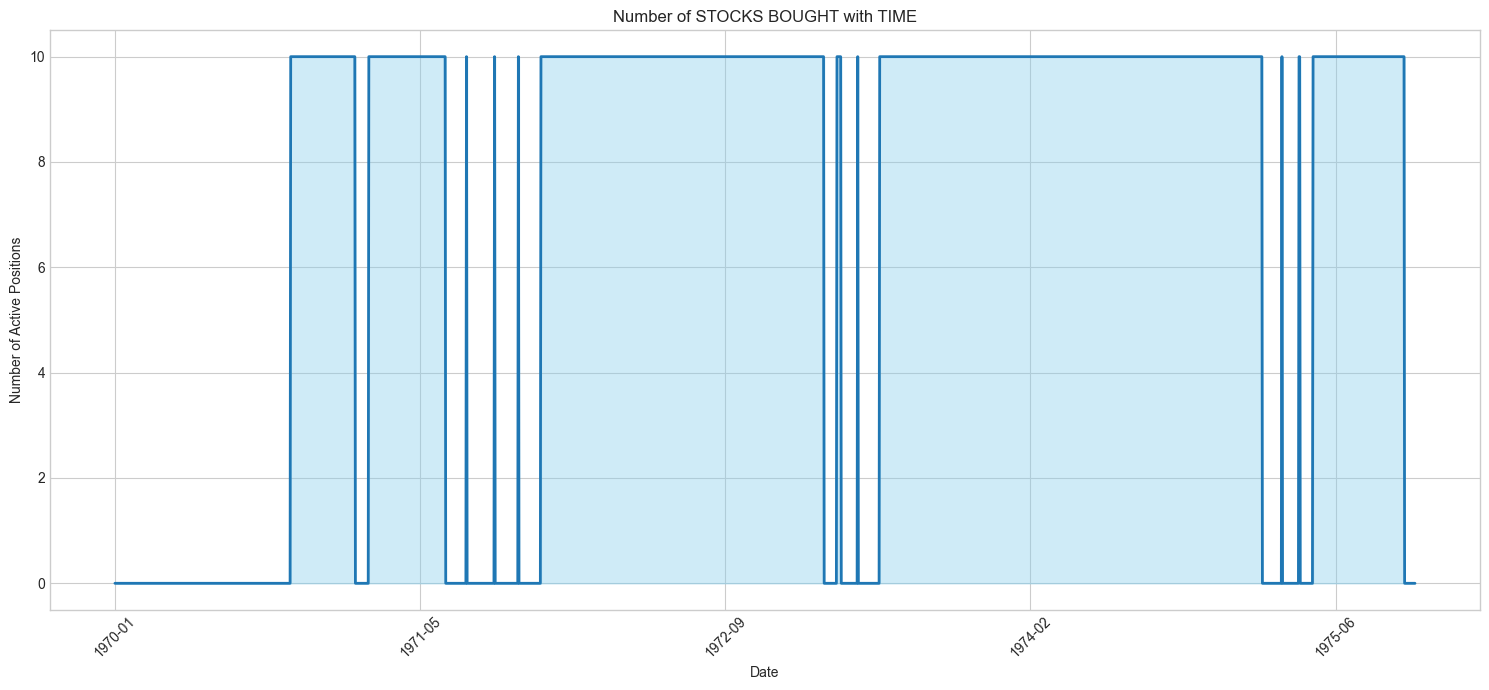

Percentage of CAPITAL INVESTED with TIME


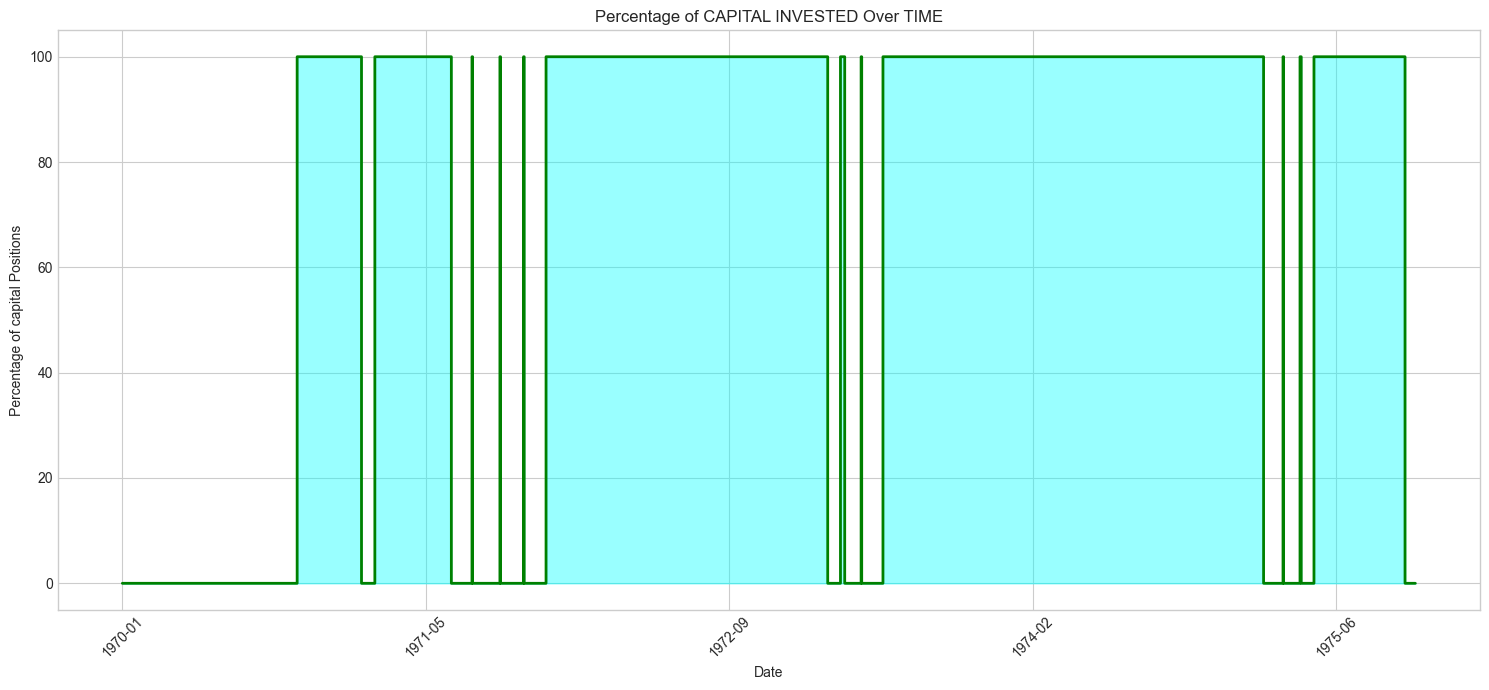

In [24]:

weights_df = pd.read_csv('auxilary/backtester_weights.csv', index_col=0, parse_dates=True)
print("---------------Successfully loaded 'results/signals.csv'---------------")

print("Number of STOCKS BOUGHT with TIME")
weights_df=weights_df.ffill()
weights_df=weights_df[TRADING_START_DATE:END_DATE]
invested_stocks_count = (weights_df > 0).sum(axis=1)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))
invested_stocks_count.plot(
    ax=ax,
    title='Number of STOCKS BOUGHT with TIME',
    xlabel='Date',
    ylabel='Number of Active Positions',
    lw=2
)
ax.fill_between(
        invested_stocks_count.index, 
        invested_stocks_count.values, 
        step='post', 
        color='skyblue', 
        alpha=0.4 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()



print("Percentage of CAPITAL INVESTED with TIME")
weights_df = pd.read_csv('auxilary/backtester_weights.csv', index_col=0, parse_dates=True)
weights_df=weights_df*100
weights_df=weights_df.ffill()
weights_df=weights_df[TRADING_START_DATE:END_DATE]
invested_stocks_count = weights_df.sum(axis=1)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))
invested_stocks_count.plot(
    ax=ax,
    title='Percentage of CAPITAL INVESTED Over TIME',
    xlabel='Date',
    ylabel='Percentage of capital Positions',
    lw=2,
    drawstyle='steps-post',
    color='green'
)
ax.fill_between(
        invested_stocks_count.index, 
        invested_stocks_count.values, 
        step='post', 
        color='cyan', 
        alpha=0.4 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()


# Looptest not working with the new backtester

In [26]:
import pandas as pd
import numpy as np
import vectorbt as vbt
from IPython.display import display

# --- 1. Load Data and Define Parameters ---
data = pd.read_csv(
    'src/all_ohlcv_clipped.csv',
    index_col=0, header=[0, 1], parse_dates=True
)
data = data.sort_index()

# ========== PARAMETER GRID FOR OPTIMIZATION ==========
# Adjust these lists to test different parameter combinations
rolling_period_list = [13,26, 39, 52,104,260]  # 12-month momentum (recommended)
mean_period_list = [52]  # Should match rolling period
skip_weeks_list = [4]  # Skip last month (recommended)
dilute_to_list = [15]
use_id_filter_list = [True, False]  # Test with and without ID filtering
id_percentile_list = [50, 30]  # Keep top 50% or 30% smoothest stocks
benchmark_exit_multiplier_list = [BENCHMARK_EXIT_MULTIPLIER]

all_results = []
count = 0
tot = (len(rolling_period_list) * len(mean_period_list) * len(skip_weeks_list) * 
       len(dilute_to_list) * len(use_id_filter_list) * len(id_percentile_list) *
       len(benchmark_exit_multiplier_list))

print("\n" + "="*100)
print("QUANTITATIVE MOMENTUM PARAMETER OPTIMIZATION")
print("="*100)
print(f"Total combinations to test: {tot}")
print("="*100 + "\n")

# --- 2. Main Optimization Loop ---
for rolling_period in rolling_period_list:
    for mean_period in mean_period_list:
        for skip_weeks in skip_weeks_list:
            for dilute_to in dilute_to_list:
                for use_id in use_id_filter_list:
                    for id_pct in id_percentile_list:
                        for bench_mult in benchmark_exit_multiplier_list:
                            # Skip invalid combinations
                            if not use_id and id_pct != id_percentile_list[0]:
                                continue  # Don't test multiple ID percentiles when ID filter is off
                            
                            count += 1
                            print(f"\n[{count}/{tot}] Testing Parameters:")
                            print(f"  Rolling: {rolling_period} weeks | Mean: {mean_period} weeks | Skip: {skip_weeks} weeks")
                            print(f"  Dilute: {dilute_to} | ID Filter: {use_id} | ID Percentile: {id_pct if use_id else 'N/A'}")
                            print(f"  Benchmark Exit Multiplier: {bench_mult}")
                            print("-" * 80)
                            
                            # Generate momentum scores with T-12 vs T-1 ratio
                            z_scores_df, z_scores_mean_df = momentum_selector(
                                lookback_weeks=rolling_period + 1,
                                skip_recent_weeks=skip_weeks,
                                mean_period=rolling_period,
                                mode='looptest',
                            )
                            
                            # Generate ID scores if needed
                            if use_id:
                                id_scores_df = calculate_id_score(
                                    lookback_weeks=rolling_period,
                                    skip_recent_weeks=skip_weeks,
                                    mode='looptest'
                                )
                            else:
                                id_scores_df = None
                            
                            # Generate weights
                            weights_generation(
                                START_DATE, 
                                END_DATE,
                                TRADING_START_DATE, 
                                Z_MEAN,
                                dilute_to,
                                z_scores_df,
                                z_scores_mean_df,
                                id_scores_df=id_scores_df,
                                initial_capital=INITIAL_CAPITAL, 
                                number_stocks_active=NUM_STOCKS_ACTIVE, 
                                zscore_threshold=ZSCORE_THRESHOLD,
                                use_id_filter=use_id,
                                id_percentile_cutoff=id_pct,
                                rebalance_mode=REBALANCE_MODE,
                                mode='looptest',
                            )
                            
                            # Run backtest
                            fresh_strategy = Strategy_looptest()
                            backtester = Backtester(data, INITIAL_CAPITAL, TRADING_START_DATE)
                            backtester.run(mode='looptest')
                            pf = backtester.vectorbt_run(
                                rolling_period, 
                                rolling_period, 
                                ROLLING_THRESHOLD, 
                                dilute_to, 
                                mode='looptest'
                            )
                            
                            # Store results with all parameters
                            result_dict = pf.copy()
                            result_dict['skip_weeks'] = skip_weeks
                            result_dict['use_id_filter'] = use_id
                            result_dict['id_percentile'] = id_pct if use_id else np.nan
                            result_dict['benchmark_exit_multiplier'] = bench_mult
                            
                            all_results.append(result_dict)
                            
                            # Save incrementally
                            all_results_df = pd.DataFrame(all_results)
                            all_results_df.to_csv('all_results.csv', index=False)

# --- 3. Display Results ---
if all_results:
    print("\n" + "="*100)
    print("OPTIMIZATION COMPLETE - RESULTS")
    print("="*100 + "\n")
    
    results_df = pd.DataFrame(all_results)
    
    # Sort by Sharpe Ratio (or any other metric you prefer)
    results_df_sorted = results_df.sort_values('Sharpe Ratio', ascending=False)
    
    print("Top 5 Configurations by Sharpe Ratio:")
    print("="*100)
    display(results_df_sorted.head(10).round(4))
    
    print("\n✅ Full results saved to 'all_results.csv'")
else:
    print("\n❌ No results generated. Check for errors above.")


QUANTITATIVE MOMENTUM PARAMETER OPTIMIZATION
Total combinations to test: 24


[1/24] Testing Parameters:
  Rolling: 13 weeks | Mean: 52 weeks | Skip: 4 weeks
  Dilute: 15 | ID Filter: True | ID Percentile: 50
  Benchmark Exit Multiplier: 0.95
--------------------------------------------------------------------------------


TypeError: Backtester.run() got an unexpected keyword argument 'mode'